In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Ensure plots show inside Jupyter
%matplotlib inline

# Load cleaned review data
df = pd.read_csv('data/processed/task2_reviews_sentiment_theme.csv')

# Set seaborn style
sns.set(style="whitegrid")


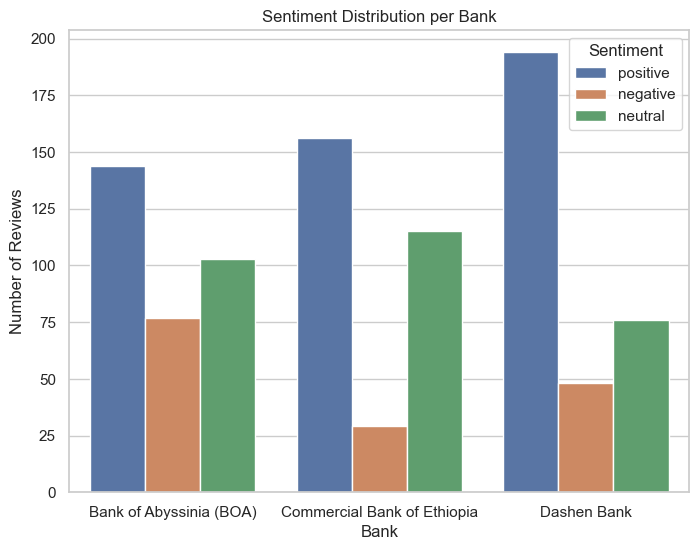

In [3]:
# -----------------------------
# 1. Sentiment Distribution per Bank
# -----------------------------
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='bank_name', hue='vader_sentiment')
plt.title('Sentiment Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()

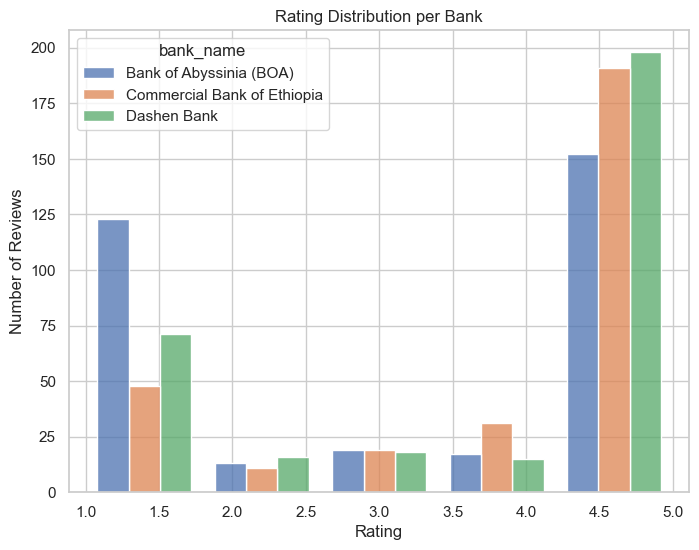

In [4]:
# -----------------------------
# 2. Rating Distribution per Bank
# -----------------------------
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='rating', hue='bank_name', multiple='dodge', bins=5, shrink=0.8)
plt.title('Rating Distribution per Bank')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

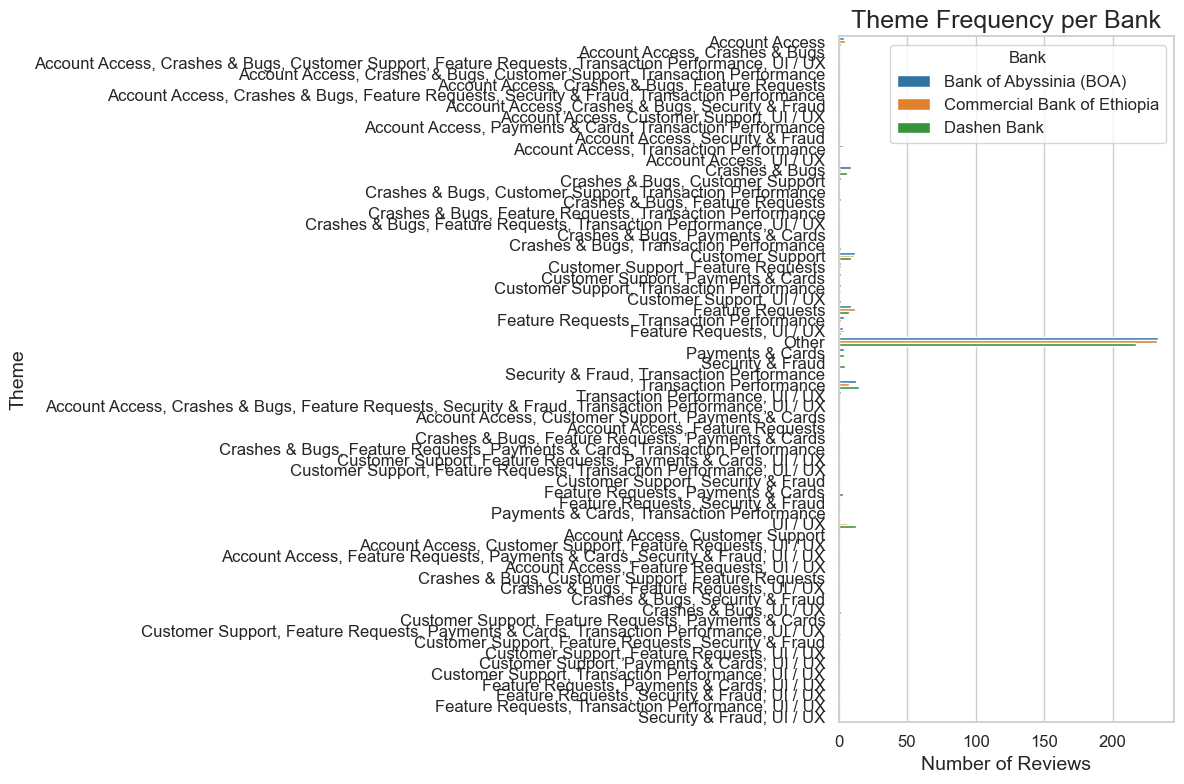

In [12]:
# -----------------------------
# 3. Theme Frequency per Bank 
# -----------------------------
theme_counts = df.groupby(['bank_name', 'themes_str']).size().reset_index(name='count')

# Assign strong distinct colors to each bank
bank_colors = {
    'Bank of Abyssinia (BOA)': '#1f77b4',      # dark blue
    'Commercial Bank of Ethiopia': '#ff7f0e',  # orange
    'Dashen Bank': '#2ca02c'                   # green
}

plt.figure(figsize=(12,8))
sns.barplot(
    data=theme_counts,
    y='themes_str',      # switch axes
    x='count',
    hue='bank_name',
    palette=bank_colors
)
plt.title('Theme Frequency per Bank', fontsize=18)
plt.xlabel('Number of Reviews', fontsize=14)
plt.ylabel('Theme', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)  # keep y labels horizontal for readability
plt.legend(title='Bank', fontsize=12)
plt.tight_layout()  # prevents cutting off labels
plt.show()


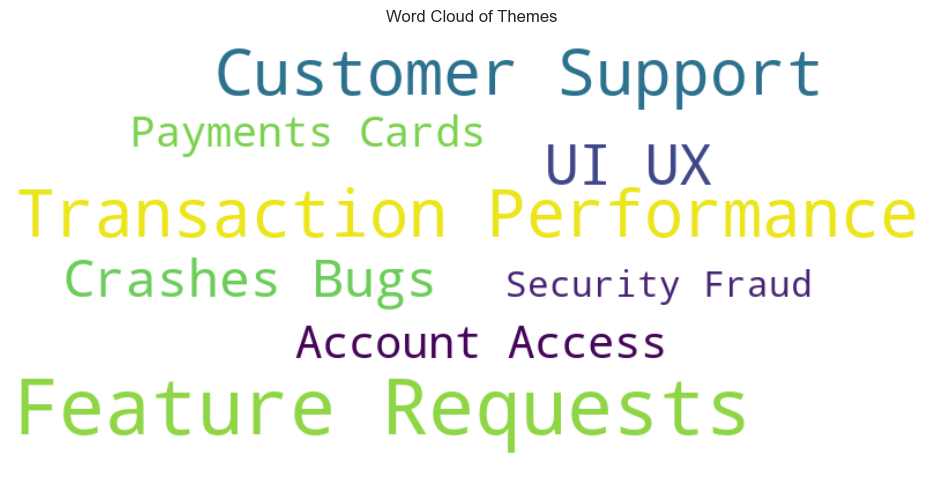

In [6]:
# -----------------------------
# 4. Word Cloud of Themes
# -----------------------------
all_themes = " ".join(df['themes_str'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_themes)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Themes')
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_4580\2477275168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_rating, x='bank_name', y='rating', palette='pastel')


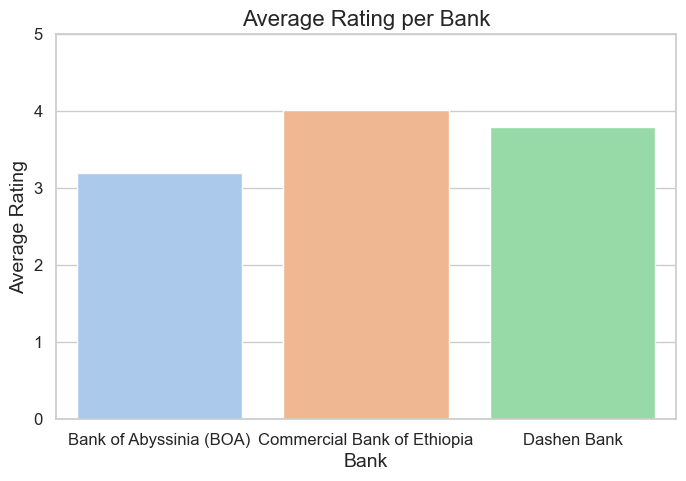

In [8]:
plt.figure(figsize=(8,5))  # make figure wider if needed
sns.barplot(data=avg_rating, x='bank_name', y='rating', palette='pastel')
plt.title('Average Rating per Bank', fontsize=16)
plt.ylabel('Average Rating', fontsize=14)
plt.xlabel('Bank', fontsize=14)
plt.xticks(fontsize=12)  # change font size of x-axis labels
plt.yticks(fontsize=12)  # change font size of y-axis labels
plt.ylim(0,5)
plt.show()
